In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Problem parameters
CAPACITY = 100
ROOM_PRICE = 125
VARIABLE_COST = 30
PROFIT_PER_ROOM = ROOM_PRICE - VARIABLE_COST

NO_SHOW_PROB = 0.05
SHOW_PROB = 1 - NO_SHOW_PROB

OVERBOOKING_COST = 200
N_SIMULATIONS = 500


def simulate_day(reservations):
    """
    Simulates one day of hotel operations for a given number of reservations.
    """

    arrivals = np.random.binomial(n=reservations, p=SHOW_PROB)

    occupied_rooms = min(arrivals, CAPACITY)
    excess_customers = max(arrivals - CAPACITY, 0)

    profit = (
        occupied_rooms * PROFIT_PER_ROOM
        - excess_customers * OVERBOOKING_COST
    )

    return {
        "arrivals": arrivals,
        "occupied_rooms": occupied_rooms,
        "excess_customers": excess_customers,
        "profit": profit
    }


def evaluate_reservations(reservations, n_sim=N_SIMULATIONS):
    """
    Runs multiple simulations for a given reservation level
    and returns summary statistics.
    """
    print("Running with number of reservations:", reservations)
    simulations = [simulate_day(reservations) for _ in range(n_sim)]
    df = pd.DataFrame(simulations)

    return {
        "reservations": reservations,
        "avg_profit": df["profit"].mean(),
        "std_profit": df["profit"].std(),
        "overbooking_probability": (df["excess_customers"] > 0).mean(),
        "avg_occupancy": df["occupied_rooms"].mean()
    }

Monte Carlo simulation with 500 runs per policy
Running with number of reservations: 100
Running with number of reservations: 101
Running with number of reservations: 102
Running with number of reservations: 103
Running with number of reservations: 104
Running with number of reservations: 105
Running with number of reservations: 106
Running with number of reservations: 107
Running with number of reservations: 108
Running with number of reservations: 109
Running with number of reservations: 110
    reservations  avg_profit  std_profit  overbooking_probability  \
0            100     9026.90  212.204976                    0.000   
1            101     9127.77  200.163203                    0.002   
2            102     9177.74  208.514866                    0.038   
3            103     9253.40  176.787011                    0.118   
4            104     9283.93  168.638023                    0.218   
5            105     9246.21  213.791955                    0.392   
6            106  

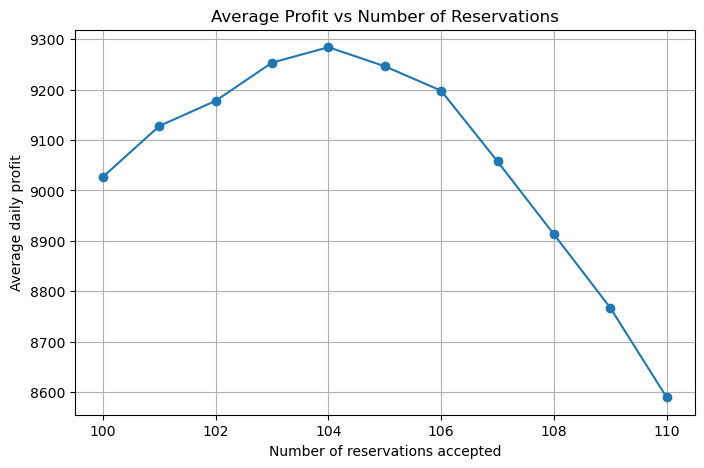

In [2]:
# Evaluate different reservation policies
print("Monte Carlo simulation with", N_SIMULATIONS, "runs per policy")
results = [evaluate_reservations(r) for r in range(100, 111)]
results_df = pd.DataFrame(results)

print(results_df)

# Best reservation policy
best_policy = results_df.loc[results_df["avg_profit"].idxmax()]
print("\nBest reservation policy:")
print(best_policy)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(results_df["reservations"], results_df["avg_profit"], marker="o")
plt.xlabel("Number of reservations accepted")
plt.ylabel("Average daily profit")
plt.title("Average Profit vs Number of Reservations")
plt.grid(True)
plt.show()